In [50]:
words=open("names.csv",encoding="utf-8").read().splitlines()

In [ ]:
import re

clean_words = []

for w in words:

    w = re.sub(r"[^A-Za-z\s'& -]", "", w)
    w = " ".join(w.split())
    if w:
        clean_words.append(w)

words = clean_words

In [52]:
words[:10]

['lavera',
 'fairytabs',
 'arkive',
 'gaa',
 'cultiv cosmetique',
 'the green recipe',
 'mlanine',
 'base cosmetics',
 'ose',
 'moon hudvrd']

In [53]:
len(words)

33631

In [54]:
min(len(w) for w in words)

1

In [55]:
max(len(w) for w in words)

99

BIGRAM

In [56]:
b={}
for w in words:
    chs=['<S>']+list(w)+['<E>']
    for ch1,ch2 in zip(chs,chs[1:]):
        bigram=(ch1,ch2)
        b[bigram]=b.get(bigram,0)+1
        



In [57]:
sorted(b.items(),key=lambda kv:-kv[1])

[(('e', ' '), 9277),
 ((' ', 's'), 8834),
 (('i', 'n'), 8513),
 (('t', 'i'), 8339),
 (('c', 'o'), 8312),
 (('a', 'l'), 8156),
 ((' ', 'c'), 7842),
 (('o', 'n'), 7571),
 (('s', ' '), 7426),
 (('a', 'r'), 7288),
 (('i', 'c'), 6970),
 (('e', 'r'), 6740),
 (('a', 'n'), 6336),
 (('o', 's'), 6210),
 (('m', 'e'), 6158),
 (('a', ' '), 6154),
 ((' ', 'l'), 5945),
 (('y', ' '), 5826),
 ((' ', 'b'), 5815),
 (('s', '<E>'), 5690),
 (('r', 'e'), 5372),
 (('b', 'e'), 5276),
 (('e', 's'), 5237),
 (('e', 'a'), 5187),
 (('m', 'a'), 5178),
 (('n', ' '), 5172),
 (('e', 't'), 5139),
 (('l', 'o'), 5105),
 (('h', 'a'), 4968),
 (('s', 'a'), 4917),
 (('u', 't'), 4880),
 (('r', 'a'), 4775),
 (('r', ' '), 4737),
 (('t', 'e'), 4691),
 (('s', 't'), 4518),
 (('n', 'a'), 4467),
 (('s', 'm'), 4455),
 (('l', 'i'), 4426),
 (('a', 'i'), 4376),
 (('o', 'r'), 4315),
 (('l', 'a'), 4239),
 (('e', 'n'), 4235),
 (('a', 'u'), 4080),
 (('t', 'y'), 4026),
 (('r', 'i'), 3857),
 (('i', 'o'), 3798),
 (('<S>', 's'), 3727),
 (('a', '

In [58]:
import torch

In [71]:
N=torch.zeros((31,31),dtype=torch.int32)

In [78]:
chars=sorted(list(set(' '.join(words))))
stoi={s:i+1 for i,s in enumerate(chars)}
stoi['.']=0

In [79]:

for w in words:
    chs=['.']+list(w)+['.']
    for ch1,ch2 in zip(chs,chs[1:]):
        ix1=stoi[ch1]
        ix2=stoi[ch2]
        N[ix1,ix2]+=1

In [80]:
N

tensor([[    0,  1445,     6,   702,  2881,  8293, 10645,  5371,  3259,  2727,
          2929,  4130,  4642,  1236,  1393,  6871,  4575,  4004,  2557,  4367,
          2020,  1109,  9876,  5273,  2389,   927,  1213,   497,   350,   377,
           194],
        [ 1442,     0,  1445,     6,   711,  2896,  5838,  7850,  3007,  1774,
          1371,  1677,  3046,  3170,   359,   766,  5959,  2491,  1736,  1236,
          3692,    81,   996,  8839,  1548,   671,   577,   561,    38,   291,
           144],
        [   26,  1442,     2,     0,    68,    19,    27,    30,    42,     4,
             4,    19,    15,     2,     4,    15,    12,    24,    39,     5,
             4,     4,   429,    10,    11,     2,     2,     2,     1,     3,
             7],
        [  715,    26,     0,     5,    26,   111,    69,    30,    24,    43,
            13,    21,    26,    15,    24,    35,    45,    20,    23,    62,
             2,    15,    56,   464,    91,    18,     4,     5,     2,     4,
 

In [81]:
itos={i:s for s,i in stoi.items()}
itos

{1: ' ',
 2: '&',
 3: "'",
 4: '-',
 5: 'a',
 6: 'b',
 7: 'c',
 8: 'd',
 9: 'e',
 10: 'f',
 11: 'g',
 12: 'h',
 13: 'i',
 14: 'j',
 15: 'k',
 16: 'l',
 17: 'm',
 18: 'n',
 19: 'o',
 20: 'p',
 21: 'q',
 22: 'r',
 23: 's',
 24: 't',
 25: 'u',
 26: 'v',
 27: 'w',
 28: 'x',
 29: 'y',
 30: 'z',
 0: '.'}

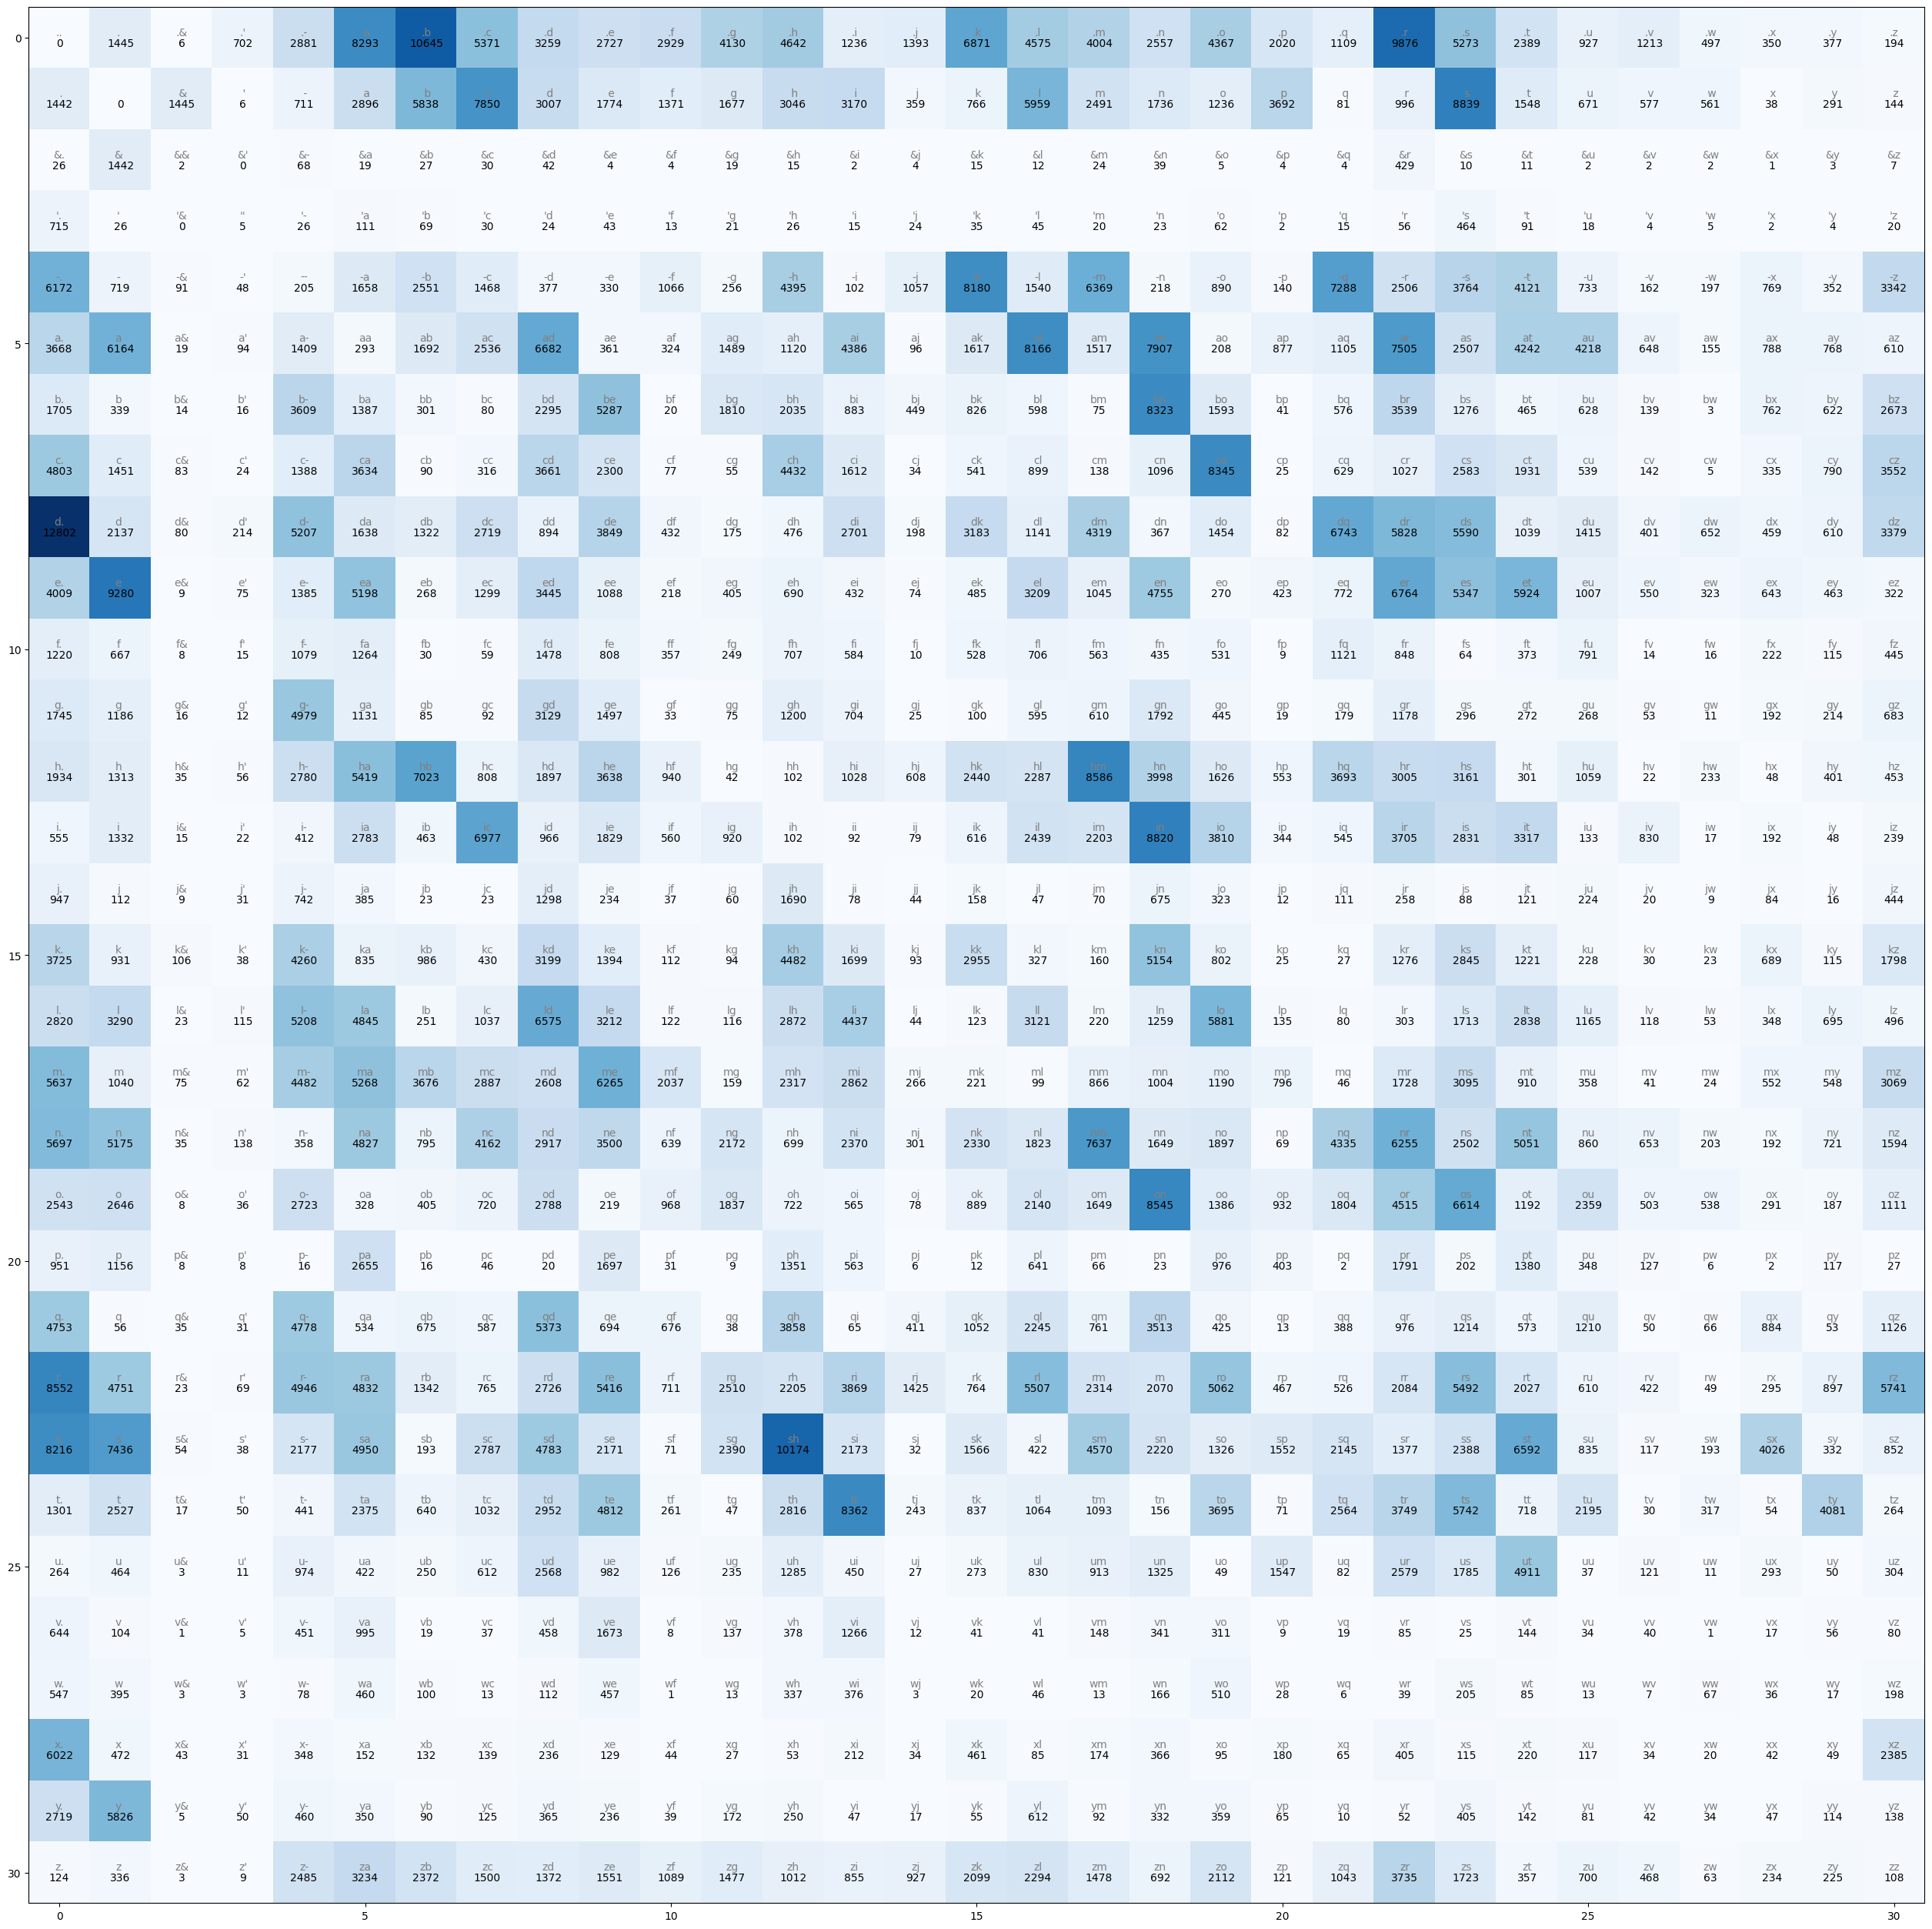

In [82]:
import matplotlib.pyplot as plt
%matplotlib inline
plt.figure(figsize=(32,32))
plt.imshow(N,cmap='Blues')
for i in range(31):
    for j in range(31):
        chstr=itos[i]+itos[j]
        plt.text(j,i,chstr,ha="center",va="bottom",color='gray')
        plt.text(j,i,N[i,j].item(),ha="center",va="top",color="black")



